In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load feature-engineered dataset
df = pd.read_csv("FinMark_Customer_Features.csv")

df.head()

,Customer_ID,Total_Transactions,Total_Amount,Avg_Transaction_Amount,Max_Transaction_Amount,Days_Since_Last_Transaction,Satisfaction_Score,Likelihood_to_Recommend
0,1,6,16836.0,2806.0,4993.0,951,10.0,9
1,1,6,16836.0,2806.0,4993.0,951,7.0,9
2,2,2,4907.0,2453.5,2850.0,992,3.0,3
3,2,2,4907.0,2453.5,2850.0,992,7.0,5
4,2,2,4907.0,2453.5,2850.0,992,3.0,7


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  5015 non-null   int64  
 1   Total_Transactions           5015 non-null   int64  
 2   Total_Amount                 5015 non-null   float64
 3   Avg_Transaction_Amount       5015 non-null   float64
 4   Max_Transaction_Amount       5015 non-null   float64
 5   Days_Since_Last_Transaction  5015 non-null   int64  
 6   Satisfaction_Score           5015 non-null   float64
 7   Likelihood_to_Recommend      5015 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 313.6 KB


,Customer_ID,Total_Transactions,Total_Amount,Avg_Transaction_Amount,Max_Transaction_Amount,Days_Since_Last_Transaction,Satisfaction_Score,Likelihood_to_Recommend
count,5015.000000,5015.000000,5015.000000,5015.000000,5015.000000,5015.000000,5015.000000,5015.000000
mean,502.210768,5.109272,15718.090927,3005.698472,7069.549551,963.284148,5.686374,5.567099
std,288.787662,2.253222,33596.094088,6393.961795,32481.853734,36.277110,3.572871,2.872270
min,1.000000,1.000000,286.000000,286.000000,286.000000,925.000000,1.000000,1.000000
25%,253.000000,3.000000,7803.500000,1993.666667,3520.000000,936.000000,3.000000,3.000000
50%,504.000000,5.000000,11859.000000,2446.666667,4329.000000,953.000000,6.000000,6.000000
75%,750.500000,7.000000,16790.000000,2917.000000,4738.000000,980.000000,8.000000,8.000000
max,1000.000000,14.000000,489516.000000,144144.000000,480300.000000,1123.000000,60.000000,10.000000


In [3]:
features = df[[
    'Total_Transactions',
    'Total_Amount',
    'Avg_Transaction_Amount',
    'Max_Transaction_Amount',
    'Days_Since_Last_Transaction',
    'Satisfaction_Score',
    'Likelihood_to_Recommend'
]]

In [4]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 164.9 kB/s  0:00:37m0:00:0200:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 347.1 kB/s  0:01:17m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

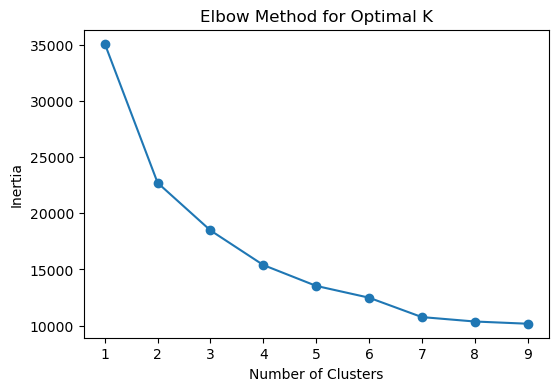

In [6]:
from sklearn.cluster import KMeans

inertia = []

k_range = range(1,10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(scaled_features)

df.head()

,Customer_ID,Total_Transactions,Total_Amount,Avg_Transaction_Amount,Max_Transaction_Amount,Days_Since_Last_Transaction,Satisfaction_Score,Likelihood_to_Recommend,Cluster
0,1,6,16836.0,2806.0,4993.0,951,10.0,9,0
1,1,6,16836.0,2806.0,4993.0,951,7.0,9,0
2,2,2,4907.0,2453.5,2850.0,992,3.0,3,2
3,2,2,4907.0,2453.5,2850.0,992,7.0,5,2
4,2,2,4907.0,2453.5,2850.0,992,3.0,7,2


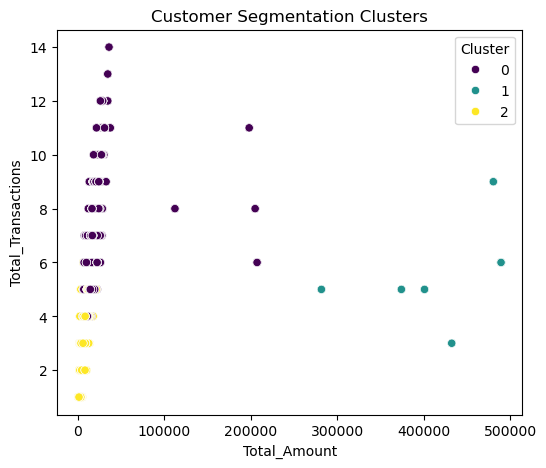

In [8]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x='Total_Amount',
    y='Total_Transactions',
    hue='Cluster',
    palette='viridis'
)

plt.title("Customer Segmentation Clusters")
plt.show()

In [9]:
cluster_summary = df.groupby('Cluster').mean()

cluster_summary

,Customer_ID,Total_Transactions,Total_Amount,Avg_Transaction_Amount,Max_Transaction_Amount,Days_Since_Last_Transaction,Satisfaction_Score,Likelihood_to_Recommend
Cluster,,,,,,,,
0,505.959089,6.495909,17757.247599,2687.808010,5766.920669,945.053362,5.491764,5.394522
1,447.428571,5.642857,416828.714286,80477.285714,405296.428571,956.571429,6.000000,6.642857
2,498.073529,3.311121,7922.517923,2419.478640,3628.068474,986.921415,5.933739,5.776195


In [10]:
df.to_csv("FinMark_Customer_Clusters.csv", index=False)